numpy pandas matplotlib satatsmodel scipy sickit-learn

# 1. Time Series Dataset Preparation and Creation 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout



## 1.1 Load Data

In [15]:
train_data = pd.read_csv("time_series_hw_data/train.csv")
test_data = pd.read_csv("time_series_hw_data/test.csv")

### Shapes of data

In [4]:
print("shape of train data:", train_data.shape)
print("shape of test data:", test_data.shape)

shape of train data: (3000888, 6)
shape of test data: (28512, 5)


### Columns Name 

In [5]:
print("name of train data cols:", train_data.columns)
print("name of test data cols:", test_data.columns)

name of train data cols: Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='str')
name of test data cols: Index(['id', 'date', 'store_nbr', 'family', 'onpromotion'], dtype='str')


### Columns Type

In [6]:
print("types of train data cols:\n", train_data.dtypes)
print("\ntypes of test data cols:\n", test_data.dtypes)

types of train data cols:
 id               int64
date               str
store_nbr        int64
family             str
sales          float64
onpromotion      int64
dtype: object

types of test data cols:
 id             int64
date             str
store_nbr      int64
family           str
onpromotion    int64
dtype: object


### Find Missing Value

In [7]:
train_data.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

### Time Range in train.csv

In [36]:
print("Train date range:")
print("Start:", train_data["date"].min())
print("End:", train_data["date"].max())

Train date range:
Start: 2013-01-01 00:00:00
End: 2017-08-15 00:00:00


### Start and End Dates in test.csv

In [16]:
print("Train date range:")
print("Start:", test_data["date"].min())
print("End:", test_data["date"].max())

Train date range:
Start: 2017-08-16
End: 2017-08-31


## 1.2 Converting the Datetime Column

In [37]:
# Convert date column to datetime
train_data["date"] = pd.to_datetime(train_data["date"])
test_data["date"] = pd.to_datetime(test_data["date"])

In [18]:
# Sort by date
train_data = train_data.sort_values("date")
test_data = test_data.sort_values("date")

In [23]:
# Check whether every day exists
full_date_range = pd.date_range(
    start=train_data["date"].min(),
    end=train_data["date"].max(),
    freq="D"
)
existing_dates = pd.to_datetime(train_data["date"].dt.date).unique()

missing_dates = full_date_range[
    ~full_date_range.normalize().isin(existing_dates)
]

print("\nAre all days present?", len(missing_dates) == 0)

if len(missing_dates) > 0:
    print("Missing dates:")
    print(missing_dates)


Are all days present? False
Missing dates:
DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[us]', freq=None)


In [21]:
# Number of days in train data
num_days_train = train_data["date"].dt.date.nunique()
num_days_test = test_data["date"].dt.date.nunique()
print("Number of days in train:", num_days_train)
print("Number of days in train:", num_days_test)

Number of days in train: 1684
Number of days in train: 16


## 1.3 Creating a Time Series of Total Sale 

In [76]:
daily_sales = train_data.groupby("date", as_index=False)["sales"].sum()
daily_sales = daily_sales.rename(columns={"sales": "total_sales"})
daily_sales.head()

,date,total_sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


## 1.4 Analytical Question

**Why is random data splitting not appropriate for time series problems, unlike in conventional machine learning?**

The key reason is that time series data has a temporal order. Future observations should not be used to train a model that is supposed to predict the past or present. Random splitting can cause data leakage and produce overly optimistic evaluation results.

# 2 Time Series Visualization and Analysis

## 2.1 Sales Visualization

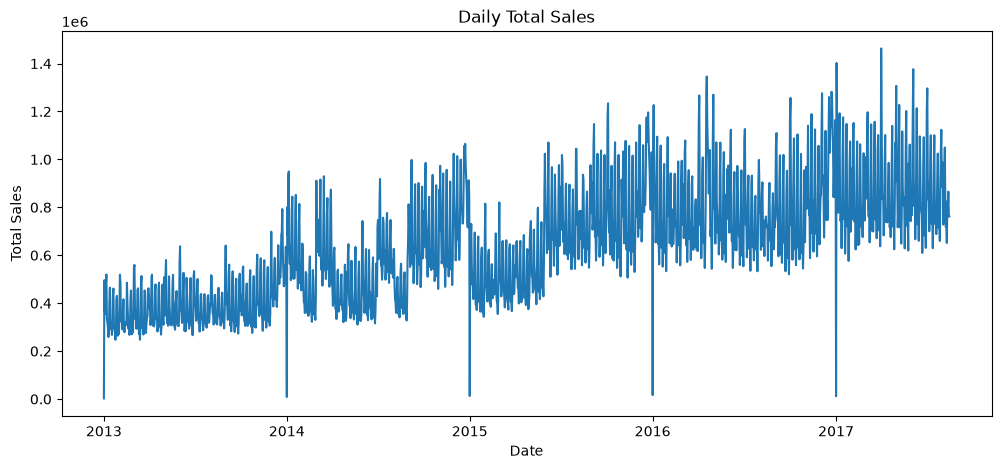

In [77]:
plt.figure(figsize=(12, 5))
plot = plt.plot(daily_sales["date"], daily_sales["total_sales"])
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Daily Total Sales")
plt.show()

## 2.2 Analyzing Sales Over Different Time Periods

### Weekly sales using resample

In [80]:
df = daily_sales.set_index("date")
weekly_sales = df["total_sales"].resample("W").sum()
weekly_sales


date
2013-01-06    2.211570e+06
2013-01-13    2.373618e+06
2013-01-20    2.368007e+06
2013-01-27    2.272165e+06
2013-02-03    2.476891e+06
                  ...     
2017-07-23    5.744335e+06
2017-07-30    5.921812e+06
2017-08-06    6.410194e+06
2017-08-13    5.385402e+06
2017-08-20    1.523584e+06
Freq: W-SUN, Name: total_sales, Length: 242, dtype: float64

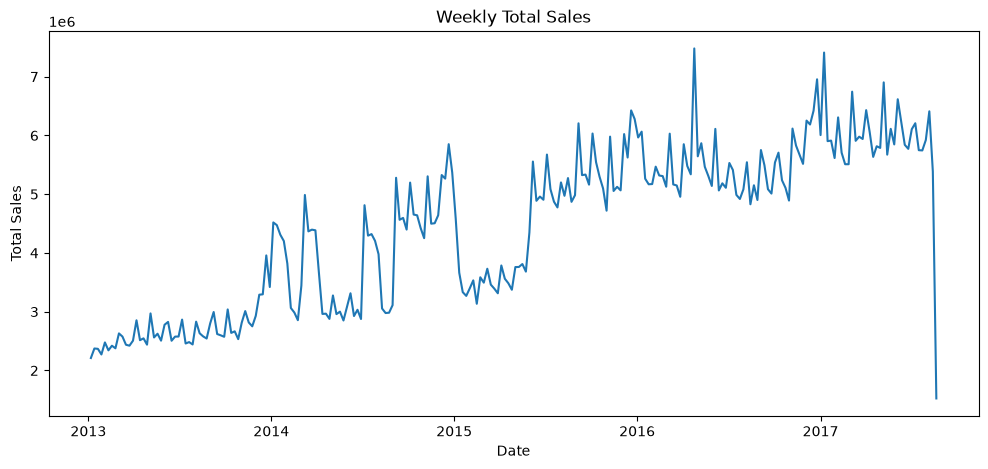

In [81]:
plt.figure(figsize=(12, 5))

plt.plot(weekly_sales.index, weekly_sales.values)

plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Weekly Total Sales")

plt.show()

### Monthly sales using resample

In [85]:
monthly_sales = df["total_sales"].resample("ME").sum()

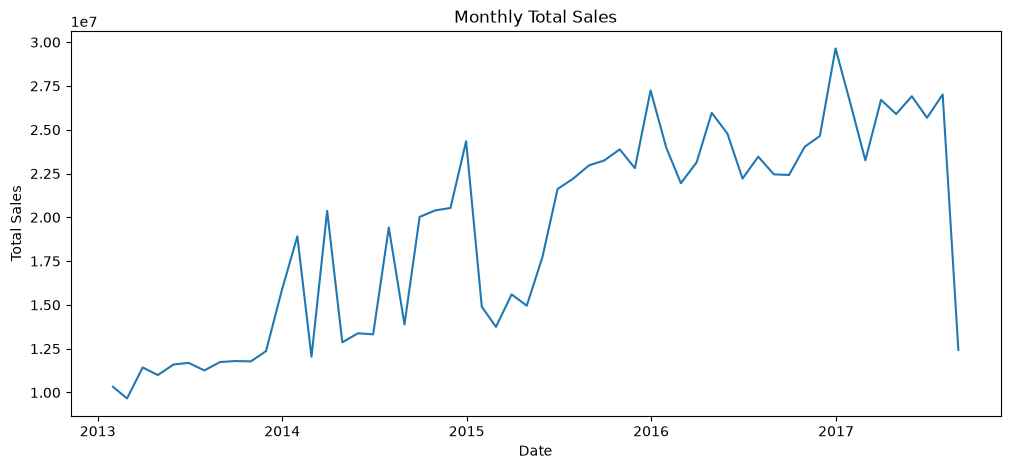

In [132]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Monthly Total Sales")

plt.show()

## 2.3 Identifying Temporal Patterns 

In [94]:
daily_sales["date"] = pd.to_datetime(daily_sales["date"])

In [97]:
daily_sales["year"] = daily_sales["date"].dt.year
daily_sales["month"] = daily_sales["date"].dt.month
daily_sales["day_of_week"] = daily_sales["date"].dt.day_of_week
daily_sales

,date,total_sales,year,month,day_of_week
0,2013-01-01,2511.618999,2013,1,1
1,2013-01-02,496092.417944,2013,1,2
2,2013-01-03,361461.231124,2013,1,3
3,2013-01-04,354459.677093,2013,1,4
4,2013-01-05,477350.121229,2013,1,5
...,...,...,...,...,...
1679,2017-08-11,826373.722022,2017,8,4
1680,2017-08-12,792630.535079,2017,8,5
1681,2017-08-13,865639.677471,2017,8,6
1682,2017-08-14,760922.406081,2017,8,0


### Sales Monthly Average

In [102]:
monthly_avg = daily_sales.groupby("month")["total_sales"].mean()

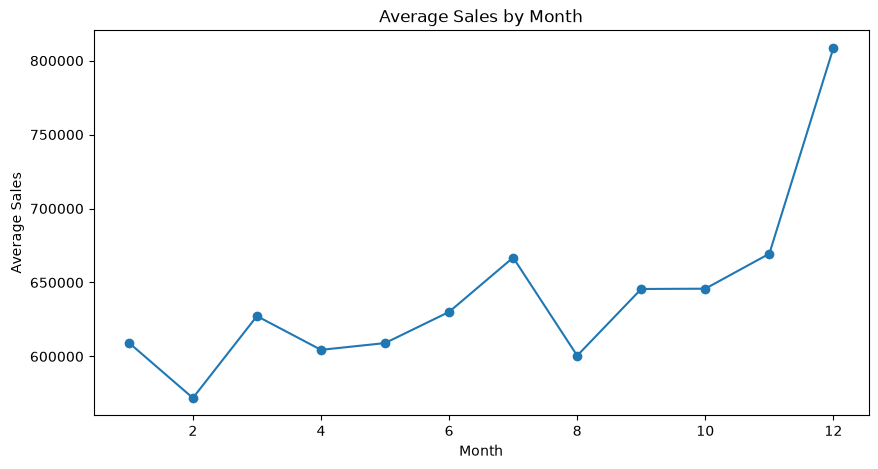

In [115]:
plt.figure(figsize=(10, 5))

plt.plot(monthly_avg.index, monthly_avg.values, marker="o")

plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.title("Average Sales by Month")

plt.show()

### Sales weekly Average

In [127]:
weekly_avg = daily_sales.groupby("day_of_week")["total_sales"].mean()

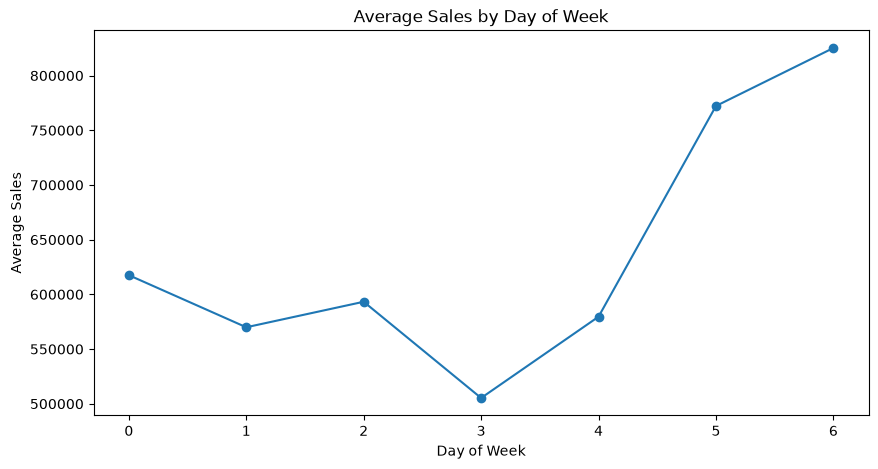

In [130]:
plt.figure(figsize=(10, 5))

plt.plot(weekly_avg.index, weekly_avg.values, marker="o")

plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.title("Average Sales by Day of Week")

plt.show()

### Sales yearly Average

In [107]:
yearly_sales = daily_sales.groupby("year")["total_sales"].sum()

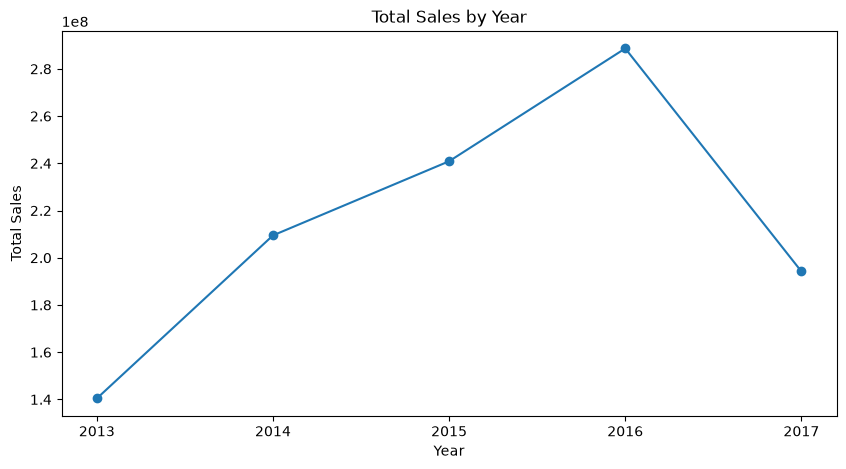

In [134]:
plt.figure(figsize=(10, 5))

plt.plot(yearly_sales.index, yearly_sales.values, marker="o")
plt.xticks(yearly_sales.index)
# plt.ticklabel_format(style="plain", axis="y")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Total Sales by Year")

plt.show()

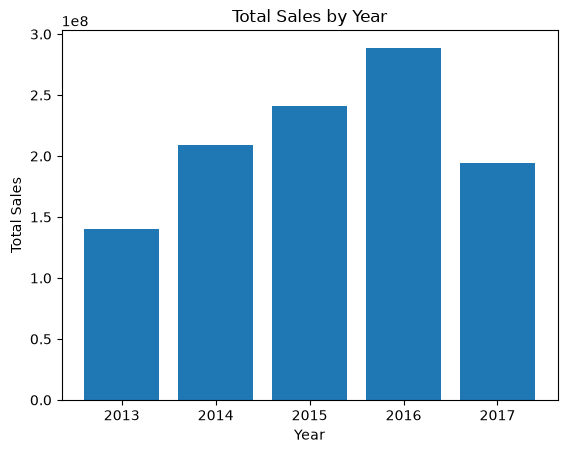

In [118]:

plt.bar(yearly_sales.index, yearly_sales.values)

plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Total Sales by Year")

plt.show()

## 2.4 Autocorrelation Analysis

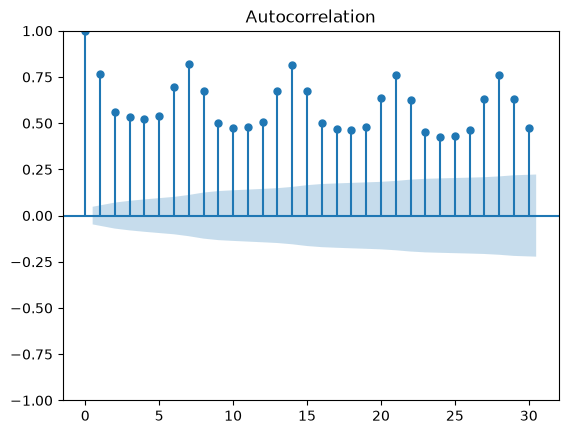

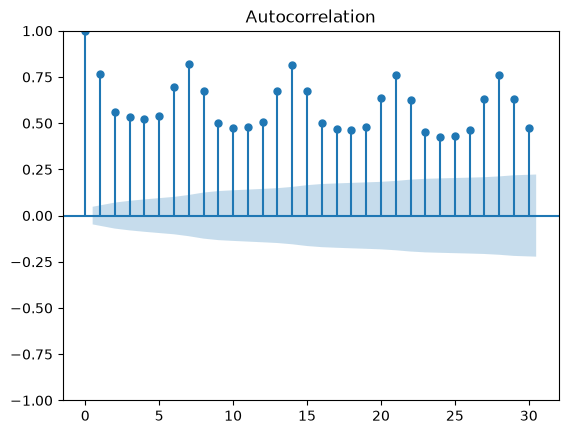

In [139]:
sales = daily_sales["total_sales"]
plot_acf(sales, lags=30)

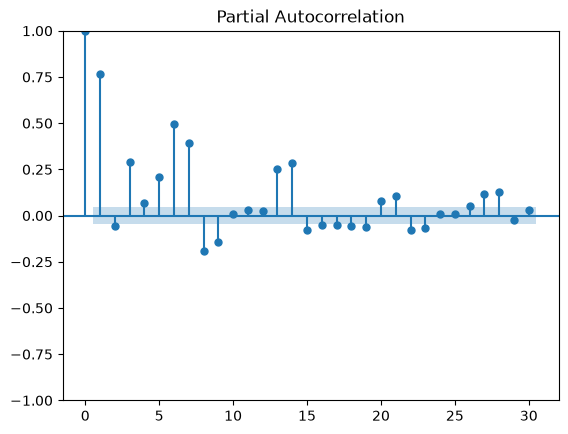

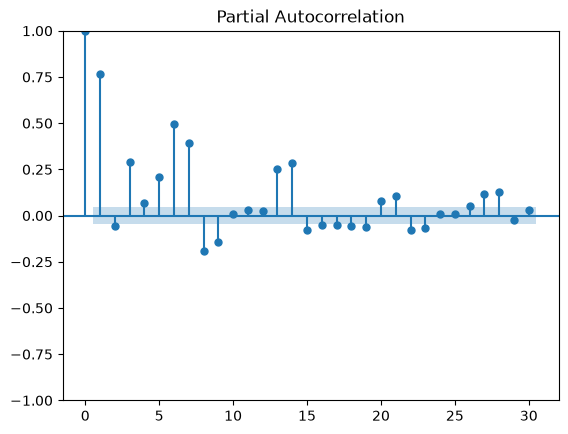

In [140]:
plot_pacf(sales, lags=30)

**Is today’s sales related to sales from previous days?**

Yes, absolutely.
There is a very strong relationship. In the ACF plot (top), the autocorrelation starts high at lag 1 (~0.75) and remains positive and above the blue confidence interval for all 30 lags shown. This means today's sales are highly dependent on the sales from previous days. The series is not random; it exhibits strong persistence.



**Which lag values are likely to be more important?**

Based on the PACF plot, the most important direct lags are 1, 3, 5, 6, 7, 8, 13, and 14. Lag 1 is overwhelmingly the most significant (~0.75). While the ACF shows peaks at 7, 14, 21, and 28, the PACF reveals that lags 21 and 28 are not directly significant once the effects of earlier lags are removed.



**Is there any evidence of a seasonal pattern?**

There is evidence of a weekly pattern in the ACF (peaks at 7, 14, 21, 28). However, the PACF shows significant spikes at 13 and 14, and no significant direct spikes at 21 and 28. This suggests that while a weekly seasonal component likely exists, the series is primarily driven by a strong short-term Autoregressive (AR) process, and the seasonality is not perfectly clean.

# 3. Stationarity Analysis and Preparation for Modeling

## 3.1 Stationarity Analysis

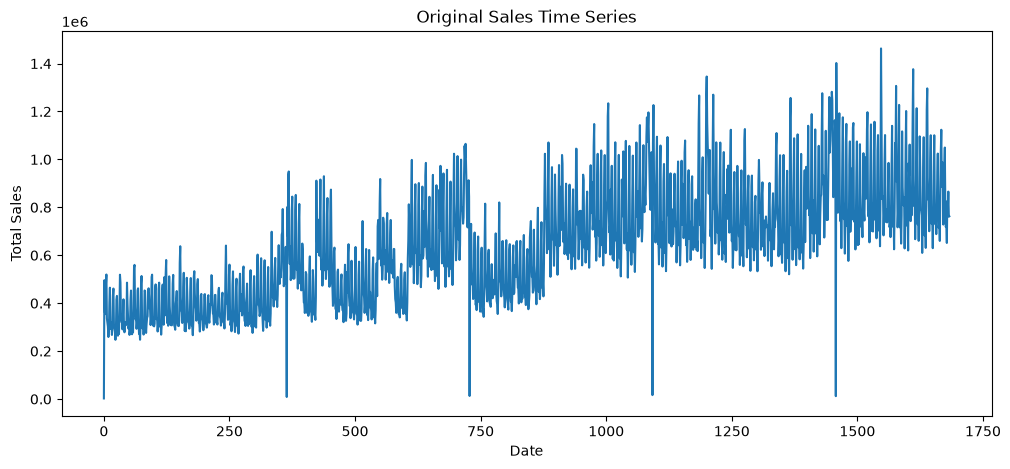

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, sales)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Original Sales Time Series")
plt.show()

In [ ]:
def check_stationary(series, name="Series"):
    """ Perform ADF test and interpret results """
    result = adfuller(series.dropna() if hasattr(series, 'dropna')else series)
    
    print(f"\n  {name}:")
    print(f"    ADF Statistic:   {result[0]:.4f}")
    print(f"    p-value:         {result[1]:.6f}")
    print(f"    Critical Values:")
    for key, value in result[4].items():
        print(f"    {key}: {value:.4f}")
    
    if result[1] < 0.05:
        print(f"    Conclusion: Stationary (reject H0, p < 0.05)")
    else:
        print(f"    Conclusion: Non-Stationary (fail to reject H0, p < 0.05)")

In [146]:
check_stationary(sales, "sales")


  sales:
    ADF Statistic:   -2.6162
    p-value:         0.089696
    Critical Values:
    1%: -3.4343
    5%: -2.8633
    10%: -2.5677
    Conclusion: Non-Stationary (fail to reject H0, p < 0.05)


/tmp/ipykernel_20865/1019846937.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna() if hasattr(series, 'dropna')else series)


## 3.2 Applying Differencing

In [152]:
diff_1 = pd.Series(sales).diff(1).dropna()

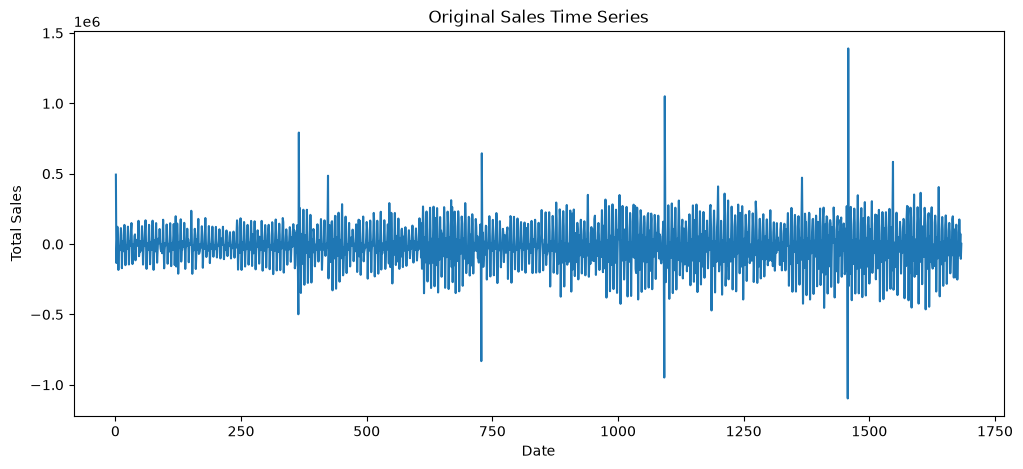

In [151]:
plt.figure(figsize=(12, 5))
plt.plot(diff_1)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Original Sales Time Series")
plt.show()

In [153]:
check_stationary(diff_1, "First Difference")


  First Difference:
    ADF Statistic:   -11.4976
    p-value:         0.000000
    Critical Values:
    1%: -3.4343
    5%: -2.8633
    10%: -2.5677
    Conclusion: Stationary (reject H0, p < 0.05)


/tmp/ipykernel_20865/1019846937.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna() if hasattr(series, 'dropna')else series)


**Comparison**

The original sales time series was tested using the Augmented Dickey-Fuller (ADF) test. The original series was non-stationary based on its p-value. Since the series was non-stationary, first-order differencing was applied. The first differencing operation produced one NaN value, which was removed. The differenced series was then plotted and tested again using the ADF test. The new p-value was below 0.05, indicating that the differenced series is stationary.

# 4. Sales Forcasting with Deep Learning, SARIMA, ARIMA

splitting data to train(80%) and validation(20%):

In [158]:
split = int(len(sales) * 0.8)

train = sales.iloc[:split]
validation = sales.iloc[split:]

In [159]:
print("Train size:", len(train))
print("Validation size:", len(validation))

Train size: 1347
Validation size: 337


## 4.1 ARIMA Model

In [ ]:
p = 1       # one autoregressive term (today depends on yesterday)
d = 1       # first-order differencing (to make the series stationary)
q = 1       # one moving-average term (today depends on yesterday's error)

p = 1 → one autoregressive term

d = 1 → first-order differencing

q = 1 → one moving-average term

In [192]:
arima_model = ARIMA(train, order=(p, d, q))
arima_result = arima_model.fit()

In [160]:
# Forecast the validation period
arima_forecast = arima_result.forecast(steps=len(validation))

In [161]:
print(len(validation))
print(len(arima_forecast))

337
337


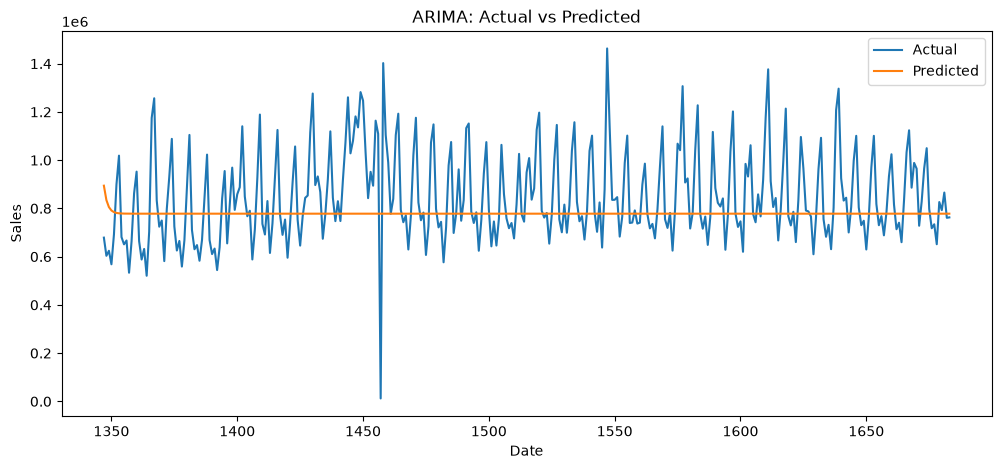

In [162]:
plt.figure(figsize=(12, 5))

plt.plot(validation.index, validation.values, label="Actual")
plt.plot(validation.index, arima_forecast, label="Predicted")

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("ARIMA: Actual vs Predicted")
plt.legend()
plt.show()

**Plot interpretation**

The forecast line follows the general level of the actual series but it is very flat and smooth — it does not reproduce the day-to-day fluctuations. This is typical of a low-order ARIMA: it captures the trend/mean but not the short-term variability.

In [166]:
mae = mean_absolute_error(validation, arima_forecast)
rmse = np.sqrt(mean_squared_error(validation, arima_forecast))
mape = np.mean(np.abs((validation - arima_forecast) / validation)) * 100

print("ARIMA Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

ARIMA Results
MAE: 143723.22243843015
RMSE: 198898.86959073585
MAPE: 34.179788324956576 %


## 4.2 SARIMA Model

The ACF analysis earlier showed peaks at lags 7, 14, 21, 28, suggesting a weekly seasonal pattern. So a Seasonal ARIMA was tried. We are modeling a seasonal pattern that repeats every 7 days.

In [194]:
period = 7

In [195]:
sarima_model = SARIMAX(
    train,
    order=(p, d, q),
    seasonal_order=(p, d, q, period)
)

In [196]:
# fit the model
sarima_result = sarima_model.fit()

In [171]:
# SARIMA Forecast
sarima_forecast = sarima_result.forecast(steps=len(validation))

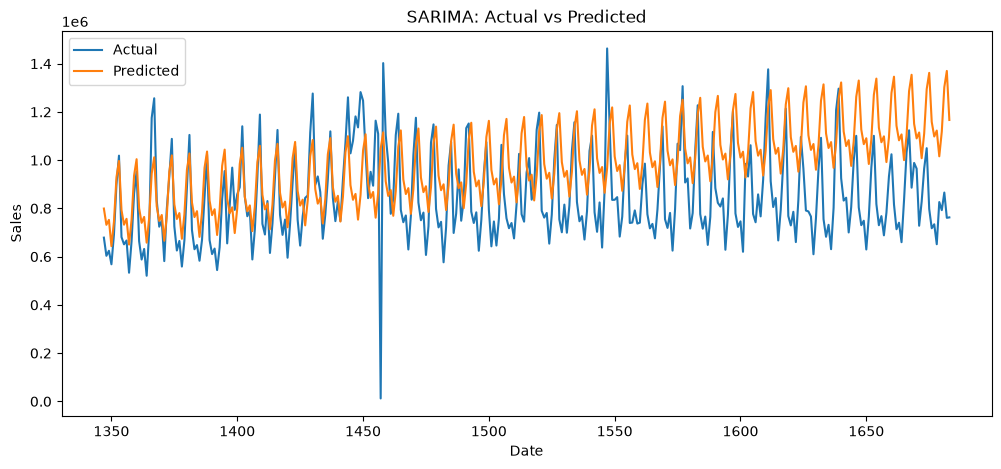

In [197]:
# Actual & Predicted Plot
plt.figure(figsize=(12, 5))

plt.plot(validation.index, validation.values, label="Actual")
plt.plot(validation.index, sarima_forecast, label="Predicted")

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("SARIMA: Actual vs Predicted")
plt.legend()
plt.show()

SARIMA performed worse than plain ARIMA on every metric. This is a counter-intuitive but instructive result:

Adding seasonal differencing (D=1) may have over-differenced the series, removing useful signal.

The seasonal order (1,1,1,7) may not be optimal.

The weekly pattern may not be strong enough (relative to noise) to justify the extra complexity.

SARIMA is also more sensitive to initial parameter estimates and can converge poorly.

So complexity (seasonal terms) did not guarantee better accuracy here.

In [173]:
mae_sarima = mean_absolute_error(validation, sarima_forecast)

rmse_sarima = np.sqrt(
    mean_squared_error(validation, sarima_forecast)
)

mape_sarima = np.mean(
    np.abs((validation - sarima_forecast) / validation)
) * 100

In [174]:
print("SARIMA Results")
print("MAE:", mae_sarima)
print("RMSE:", rmse_sarima)
print("MAPE:", mape_sarima, "%")

SARIMA Results
MAE: 189351.9177828277
RMSE: 240854.15004860982
MAPE: 49.17542301065342 %


## ARIMA & SARIMA Comparison


In [175]:
results = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA"],
    "MAE": [mae, mae_sarima],
    "RMSE": [rmse, rmse_sarima],
    "MAPE": [mape, mape_sarima]
})

print(results)

    Model            MAE           RMSE       MAPE
0   ARIMA  143723.222438  198898.869591  34.179788
1  SARIMA  189351.917783  240854.150049  49.175423


An ARIMA(1,1,1) model was trained on the training portion of the sales time series. First-order differencing (d=1) was used because the original series was non-stationary according to the ADF test. The model was used to forecast the entire validation period. The predicted values were compared with the actual values using MAE, RMSE, and MAPE.

A seasonal ARIMA model, SARIMA(1,1,1)(1,1,1,7), was trained to account for the weekly seasonal pattern observed in the ACF analysis. The seasonal period was set to 7 because the ACF showed noticeable peaks at lags 7, 14, 21, and 28. The model was evaluated on the validation set using MAE, RMSE, and MAPE.

## 4.3 Deep Learning Model

**MinMaxScaler** converts the sales values to approximately 0–1, which makes training the neural network easier. Neural networks train much better on small, bounded inputs.

In [177]:
sales = df["total_sales"].values.reshape(-1, 1)

scaler = MinMaxScaler()
sales_scaled = scaler.fit_transform(sales)

### Sequence creation

We'll use the previous 30 days to predict the next day.

In [ ]:
# Create sequences
look_back = 30

X = []
y = []

for i in range(look_back, len(sales_scaled)):
    X.append(sales_scaled[i-look_back:i])
    y.append(sales_scaled[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(1654, 30, 1)
(1654, 1)


### Train/Validation split

In [ ]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_val = X[split:]

y_train = y[:split]
y_val = y[split:]

print(X_train.shape)
print(X_val.shape)

(1323, 30, 1)
(331, 30, 1)


### Build the LSTM model

Model architecture:

LSTM(64)  →  Dropout(0.2)  →  Dense(1)

In [ ]:
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),       # regularizes to reduce overfitting
    Dense(1)            # outputs a single predicted value
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

E0000 00:00:1790963453.005124   20865 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/sanam/Desktop/ai_daneshkar_bootcamp/8_time_series/ts_venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train the model

In [184]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    shuffle=False
)

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0129 - val_loss: 0.0170
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0115 - val_loss: 0.0183
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0112 - val_loss: 0.0170
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0117 - val_loss: 0.0164
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0116 - val_loss: 0.0164
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0116 - val_loss: 0.0165
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0115 - val_loss: 0.0165
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0112 - val_loss: 0.0161
Epoch 9/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0113 - val_loss: 0.0162
Epoch 10/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0111 - val_loss: 0.0162
Epoch 11/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0108 - val_loss: 0.0162
Epoch 12/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0108 -

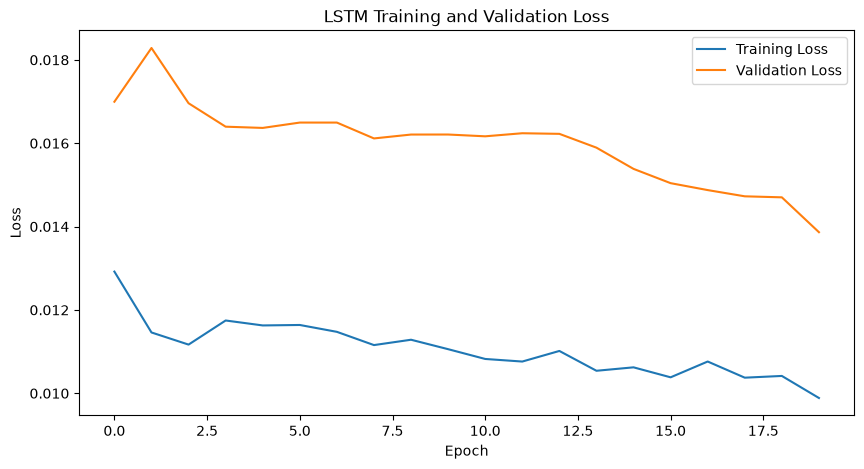

In [185]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.show()

### Make predictions

In [187]:
pred_scaled = model.predict(X_val)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


### Inverse transform

In [188]:
predicted = scaler.inverse_transform(pred_scaled)
actual = scaler.inverse_transform(y_val)

### Plot Predicted vs Actual

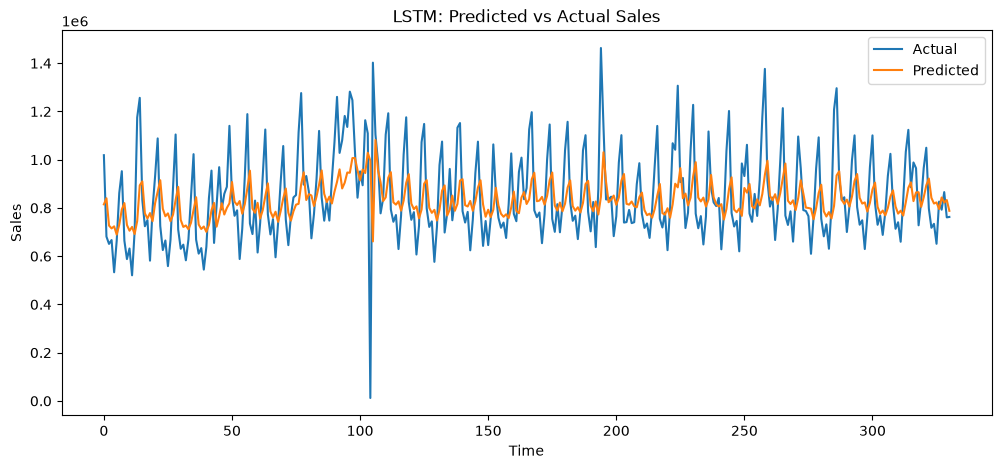

In [189]:
plt.figure(figsize=(12, 5))

plt.plot(actual, label="Actual")
plt.plot(predicted, label="Predicted")

plt.xlabel("Time")
plt.ylabel("Sales")
plt.title("LSTM: Predicted vs Actual Sales")
plt.legend()
plt.show()

**Plot interpretation**

The LSTM predicted line is noticeably wavier than ARIMA's — it tries to follow the actual fluctuations. It captures more of the short-term movement, which is why MAE and RMSE are lower.

However, MAPE is higher than ARIMA (39.23% vs 34.18%). This usually happens when the model makes large relative errors on low-sales days — absolute errors are small there, but percentage errors blow up.

### Calculate MAE, RMSE and MAPE

In [ ]:
mae = mean_absolute_error(actual, predicted)

rmse = np.sqrt(
    mean_squared_error(actual, predicted)
)

mape = np.mean(
    np.abs((actual - predicted) / actual)
) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

MAE: 131425.66618077282
RMSE: 171981.14062526493
MAPE: 39.234716529897426 %


# 5. Final Model Comparison

| Model      |            MAE |           RMSE |       MAPE |
| ---------- | -------------: | -------------: | ---------: |
| **ARIMA**  |     143,723.22 |     198,898.87 | **34.18%** |
| **SARIMA** |     189,351.92 |     240,854.15 |     49.18% |
| **LSTM**   | **131,425.67** | **171,981.14** |     39.23% |


### 1. Which model had the best performance?

Based on the results, LSTM had the lowest MAE and RMSE, while ARIMA had the lowest MAPE.

LSTM: MAE = 131,425.67, RMSE = 171,981.14
ARIMA: MAE = 143,723.22, RMSE = 198,898.87, MAPE = 34.18%
SARIMA: MAE = 189,351.92, RMSE = 240,854.15

Therefore, LSTM performed better in terms of MAE and RMSE, while ARIMA performed better in terms of MAPE.

### 2. Does the most complex model necessarily give the best result?

No. A more complex model does not necessarily provide better results.

In this experiment, LSTM was more complex than ARIMA, but ARIMA achieved a lower MAPE. This shows that model complexity alone does not guarantee better performance.

### 3. Why can a classical model such as ARIMA or SARIMA perform similarly to or even better than Deep Learning models in some situations?

ARIMA and SARIMA are specifically designed to capture temporal dependencies, trends, and seasonal patterns in time-series data. If the underlying patterns are relatively simple, these classical models can perform very well without requiring a complex neural network.

Deep Learning models such as LSTM usually require more data and careful parameter tuning to learn complex patterns effectively. Therefore, when the dataset is limited or the time-series patterns are relatively simple, ARIMA or SARIMA can achieve similar or even better performance.